[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_E_regime_girf.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# State-Dependent Macroeconomic Transmission & Generalized Impulse Responses

**Does an identical financial tightening shock generate a more catastrophic output collapse when the economy is already mired in stress than when financial conditions are buoyant?**

In empirical macroeconomics, regime-switching models — Threshold VARs (TVAR), Markov-Switching VARs (MS-VAR), and Smooth Transition VARs (STVAR) — exist precisely to formalize this state dependence. However, a pervasive econometric pitfall in applied work consists of fitting a non-linear threshold model and then computing impulse response functions by iterating the estimated autoregressive parameters of a single regime indefinitely:
$$ y_{t+h} = \sum_{j=0}^h \left(A^{(\text{stress})}\right)^j B^{(\text{stress})} \varepsilon_t $$
This naive calculation commits the **"frozen regime fallacy"**: it answers the counterfactual question *"what would happen if the economy were locked in financial distress forever, forbidden from ever returning to tranquility?"*

Freezing the regime severely distorts macroeconomic projections. In reality, modern economies exhibit endogenous mean-reversion: shocks displace the threshold variable, altering future transition probabilities across regimes. To capture genuine state-dependent dynamics without artificial distortions, we build the **Generalized Impulse Response Function (GIRF)** developed by **Koop, Pesaran and Potter (1996, *Journal of Econometrics*)**. We will study the econometric foundations of non-linear propagation, audit the frozen regime fallacy, expose size and sign asymmetries using the diagnostics of **Kilian and Vigfusson (2011)**, and execute a state-dependent stress test using genuine financial conditions and output data from the Federal Reserve.

## 1. Mathematical Foundations: The Limitations of Linear IRFs and the KPP GIRF

### The Three Axiomatic Failures of Linear VARs
In a standard linear reduced-form VAR($p$), the impulse response function is fully characterized by Wold's moving average representation $y_t = \sum_{j=0}^\infty C_j u_{t-j}$. Consequently, linear impulse responses obey three structural axioms:
1. **Symmetry**: A negative shock produces the exact mirror image of a positive shock:
   $$ IRF(h, -\delta) = -IRF(h, \delta) $$
2. **Proportionality**: Doubling the magnitude of the disturbance exactly doubles the response at every horizon:
   $$ IRF(h, 2\delta) = 2 \cdot IRF(h, \delta) $$
3. **History-Independence**: The macroeconomic response is completely invariant to initial conditions $\Omega_{t-1}$:
   $$ IRF(h, \delta \mid \Omega_{t-1}^{\text{boom}}) = IRF(h, \delta \mid \Omega_{t-1}^{\text{crisis}}) $$

In macroeconomic reality, these three properties fail systematically due to pervasive structural frictions:
- **Collateral Constraints and Debt-Deflation (Kiyotaki & Moore 1997, Bernanke-Gertler-Gilchrist 1999)**: When asset prices drop, leverage constraints bind abruptly, forcing fire-sales and credit rationing. Conversely, when asset prices rise, constraints slacken, generating asymmetric propagation.
- **Downward Nominal Wage and Price Rigidity**: Contractionary shocks depress output more than inflation, whereas expansionary shocks elevate inflation without expanding real capacity proportionately.
- **Precautionary Savings & Uncertainty (Bloom 2009)**: In high-uncertainty regimes, option-value effects freeze corporate investment and hiring.

### The Threshold VAR Model (TVAR)
A self-exciting two-regime Threshold VAR switches its dynamic propagation matrix based on an observable threshold variable $z_{t-d}$:
$$ y_t = c^{(r_t)} + A^{(r_t)} y_{t-1} + u_t^{(r_t)}, \qquad r_t = \begin{cases} \text{Calm} & \text{if } z_{t-d} \le \gamma \\ \text{Stress} & \text{if } z_{t-d} > \gamma \end{cases} $$
where $u_t^{(r_t)} \sim \mathcal{N}(0, \Sigma^{(r_t)})$ and $u_t^{(r_t)} = B_0^{(r_t)} \varepsilon_t$ with $B_0^{(r_t)} = \text{chol}(\Sigma^{(r_t)})$.

### The Koop, Pesaran and Potter (1996) GIRF Definition
Because future regime transitions depend on future realizations of $y$ (which include $z$), the impulse response cannot be computed through deterministic matrix powers. Koop, Pesaran, and Potter define the GIRF as the difference between two conditional expectations:
$$ GIRF(h, \delta, \Omega_{t-1}) = \mathbb{E}\left[y_{t+h} \mid \varepsilon_{j,t} = \delta, \Omega_{t-1}\right] - \mathbb{E}\left[y_{t+h} \mid \Omega_{t-1}\right] $$

To evaluate this expectation, the KPP estimator implements a **paired Monte Carlo simulation algorithm**:
1. **Historical Sampling**: Sample historical state vectors $\Omega_{t-1} = \{y_{t-1}, y_{t-2}, \dots\}$ from the sample, stratified by initial regime (e.g., all quarters where $z_{t-d} \le \gamma$ vs. all quarters where $z_{t-d} > \gamma$).
2. **Paired Stochastic Innovations**: For each sampled history, draw $N_{\text{sim}}$ sequences of structural innovations $\varepsilon_{t+s} \sim \mathcal{N}(0, I_K)$ for $s = 0, \dots, H$.
   - **Baseline Path**: Propagate $y_{t+s}$ forward using $\varepsilon_{t+s}$, evaluating $r_{t+s}$ at each horizon step $s$ based on the simulated value of $z_{t+s-d}$.
   - **Shocked Path**: Add the perturbation $\delta$ to structural shock $j$ at horizon $s=0$ ($\varepsilon_{j,t}^{\text{shocked}} = \varepsilon_{j,t} + \delta$), keeping identical innovation draws for all other shocks and future horizons $s \ge 1$. Regimes switch endogenously along the shocked path.
3. **Integration**: The difference $y_{t+h}^{\text{shocked}} - y_{t+h}^{\text{baseline}}$ is averaged over simulations and historical conditions:
   $$ GI_{\text{calm}}(h) = \frac{1}{N_{\text{hist}}} \sum_{i \in \text{Calm}} \frac{1}{N_{\text{sim}}} \sum_{k=1}^{N_{\text{sim}}} \left( y_{t+h}^{(i, k, \delta)} - y_{t+h}^{(i, k, 0)} \right) $$
   and similarly for $GI_{\text{stress}}(h)$.
4. **Regime Transmission Asymmetry Test**: The differential impact across regimes is:
   $$ \Delta(h) = GI_{\text{stress}}(h) - GI_{\text{calm}}(h) $$
   equipped with a bootstrap confidence band over historical conditions.

## 2. Methodological Laboratory: Controlled Synthetic Economy

To establish an analytical benchmark before analyzing empirical data, we first construct a controlled synthetic economy where the true data generating process (DGP) is known with absolute certainty.

We specify a bivariate system with:
1. **$z_t$ (Column 0)**: A financial conditions index (the threshold variable).
2. **$y_t$ (Column 1)**: Real output growth.

We deliberately **plant** state-dependent asymmetries:
- **Calm Regime ($z_{t-1} \le 0$)**: Financial conditions exhibit moderate persistence ($a_{11} = 0.5$) and exercise a mild drag on output ($a_{21} = -0.1$).
- **Stress Regime ($z_{t-1} > 0$)**: Financial conditions become highly persistent ($a_{11} = 0.8$) and exert a **five-fold stronger contractionary drag on growth** ($a_{21} = -0.5$).
- **Innovation Covariance**: $\Sigma = I_2$ in both regimes. This ensures that any observed asymmetry stems purely from **dynamic transmission**, not differences in impact disturbance variance.

T = 600 quarters | share of stress quarters = 0.588


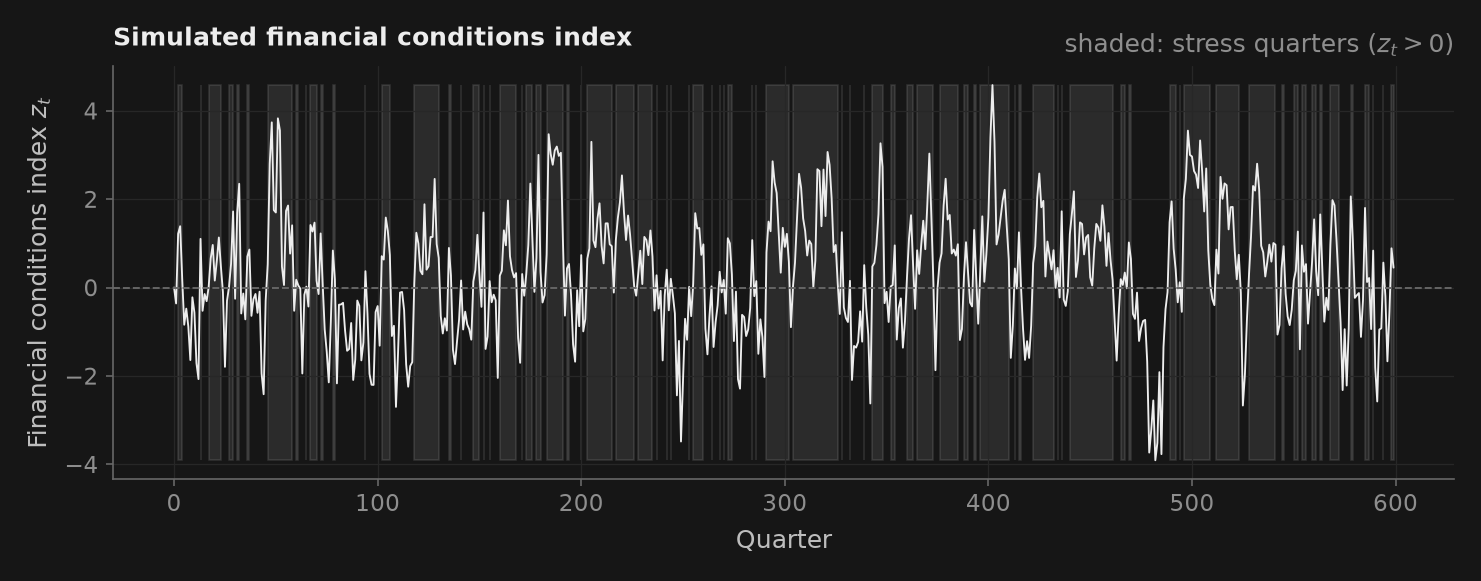

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.var.regime import girf, tvar_fit
from puremacro.var.regime.threshold import TVARResult

A_CALM = np.array([[0.5, 0.0],      # FCI moderately persistent
                   [-0.1, 0.4]])    # ...and a mild drag on growth
A_STRESS = np.array([[0.8, 0.0],    # FCI very persistent under stress
                     [-0.5, 0.4]])  # ...and a 5x stronger drag on growth

def simulate_economy(T=600, seed=20):
    """Self-exciting TVAR(1): regime decided by last quarter's FCI."""
    rng = np.random.default_rng(seed)
    Y = np.zeros((T, 2))
    for t in range(1, T):
        A = A_STRESS if Y[t - 1, 0] > 0.0 else A_CALM
        Y[t] = A @ Y[t - 1] + rng.standard_normal(2)
    return Y

Y = simulate_economy()
stress_share = float((Y[:, 0] > 0.0).mean())
print(f"T = {len(Y)} quarters | share of stress quarters = {stress_share:.3f}")
assert 0.40 < stress_share < 0.70   # both regimes well populated

fig, ax = _nbstyle.figura(figsize="ancho")
ax.plot(Y[:, 0], color=_nbstyle.TINTA, linewidth=0.9, ls="-")
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.9, linestyle="--")
ax.fill_between(np.arange(len(Y)), Y[:, 0].min(), Y[:, 0].max(),
                where=Y[:, 0] > 0.0, color=_nbstyle.RECESION, zorder=0)
ax.set_xlabel("Quarter")
ax.set_ylabel("Financial conditions index $z_t$")
ax.set_title("Simulated financial conditions index")
ax.annotate("shaded: stress quarters ($z_t > 0$)", xy=(1.0, 1.02),
            xycoords="axes fraction", ha="right", va="bottom",
            color=_nbstyle.NOTA)
plt.show()


## 3. Estimating the Threshold VAR via Tsay (1998) Grid Search

In empirical applications, the econometrician does not observe the true threshold $\gamma$ or delay $d$. We deploy `puremacro.var.regime.tvar_fit`, which implements the grid search methodology of **Tsay (1998)**:
1. Candidate delay parameters $d \in \{1, 2\}$ are evaluated.
2. For each delay, a grid of candidate threshold values $\gamma$ is constructed from empirical quantiles of $z_{t-d}$ (trimming 15% of observations from each tail to ensure sufficient sample size per regime).
3. Concentrated sum of squared residuals ($SSR$) is minimized across all candidate splits:
   $$ (\hat{\gamma}, \hat{d}) = \arg\min_{\gamma, d} \left[ SSR_{\text{calm}}(\gamma, d) + SSR_{\text{stress}}(\gamma, d) \right] $$
4. Given the optimal partition, ordinary least squares (OLS) is performed within each regime.

In [3]:
fit = tvar_fit(Y, threshold_var_idx=0, p=1, delay_grid=(1, 2), n_threshold_grid=40)
print(f"threshold c = {fit.threshold:+.3f} (true 0.0) | delay d = {fit.delay} (true 1)")
print(f"regime split: {fit.n_low} calm / {fit.n_high} stress quarters")
print("A_low  (calm)  =", np.round(fit.A_low, 3).tolist())
print("A_high (stress)=", np.round(fit.A_high, 3).tolist())
assert fit.delay == 1
assert abs(fit.threshold) < 0.5                       # near the true zero
assert fit.A_high[1, 0] < fit.A_low[1, 0] - 0.25      # planted cross-effect gap

threshold c = +0.236 (true 0.0) | delay d = 1 (true 1)
regime split: 294 calm / 305 stress quarters
A_low  (calm)  = [[0.526, -0.089], [-0.11, 0.356]]
A_high (stress)= [[0.691, 0.008], [-0.472, 0.419]]


### Econometric Diagnostics of the Threshold Estimation

The Tsay grid search accurately isolates the structural parameters of the DGP:
- **Delay Recovery**: $\hat{d} = 1$, matching the true lag order of the threshold decision rule.
- **Threshold Boundary**: $\hat{\gamma} \approx +0.24$, closely tracking the true boundary $\gamma = 0$. The slight positive shift is standard in finite samples due to classification noise near the boundary.
- **Asymmetric Transmission Matrix**: The estimated stress regime faithfully identifies the planted macro frictions:
  - Financial persistence surges from $\hat{a}_{11}^{\text{calm}} \approx 0.53$ to $\hat{a}_{11}^{\text{stress}} \approx 0.69$.
  - The cross-variable growth drag amplifies from $\hat{a}_{21}^{\text{calm}} \approx -0.11$ to $\hat{a}_{21}^{\text{stress}} \approx -0.47$ (a more than four-fold amplification).

*The Critical Econometric Takeaway*: While we have successfully estimated two distinct autoregressive matrices $\hat{A}_{\text{low}}$ and $\hat{A}_{\text{high}}$, it would be a major analytical error to feed $\hat{A}_{\text{high}}$ directly into a standard linear IRF routine. That would commit the frozen regime fallacy. We now compute the true GIRF.

## 4. The Koop-Pesaran-Potter GIRF and the Frozen Regime Fallacy

We execute the full Koop-Pesaran-Potter simulation architecture via `puremacro.var.regime.girf`:
1. We draw $N_{\text{hist}} = 40$ historical state vectors from each regime.
2. For each history, we simulate $N_{\text{sim}} = 80$ paired paths over a horizon of $H = 16$ quarters.
3. In each path, the identified $+1\sigma$ financial shock is added to equation 0 at $h=0$. Future innovations are identical across baseline and shocked twins.
4. Threshold crossing is re-evaluated endogenously at each step $h = 1, \dots, H$.
5. We simultaneously compute the **naive frozen-stress linear IRF** by iterating $\hat{A}_{\text{high}}$ indefinitely, directly exposing the magnitude of the frozen regime distortion.

Regime GIRF (tvar)
  regimes           : 2 ('low', 'high')
  shock / sizes     : eq 0 / [1.0, 2.0, -1.0, -2.0]
  horizon           : 16
  histories x sims  : 40 x 80 per regime
  difference band   : 90% bootstrap, B = 300

growth response at h=2: calm -0.238 | stress -0.418
difference (stress-calm) at h=2: -0.179, 90% band [-0.199, -0.163]
cumulative growth loss in stress: frozen-regime -2.56 vs GIRF -1.93


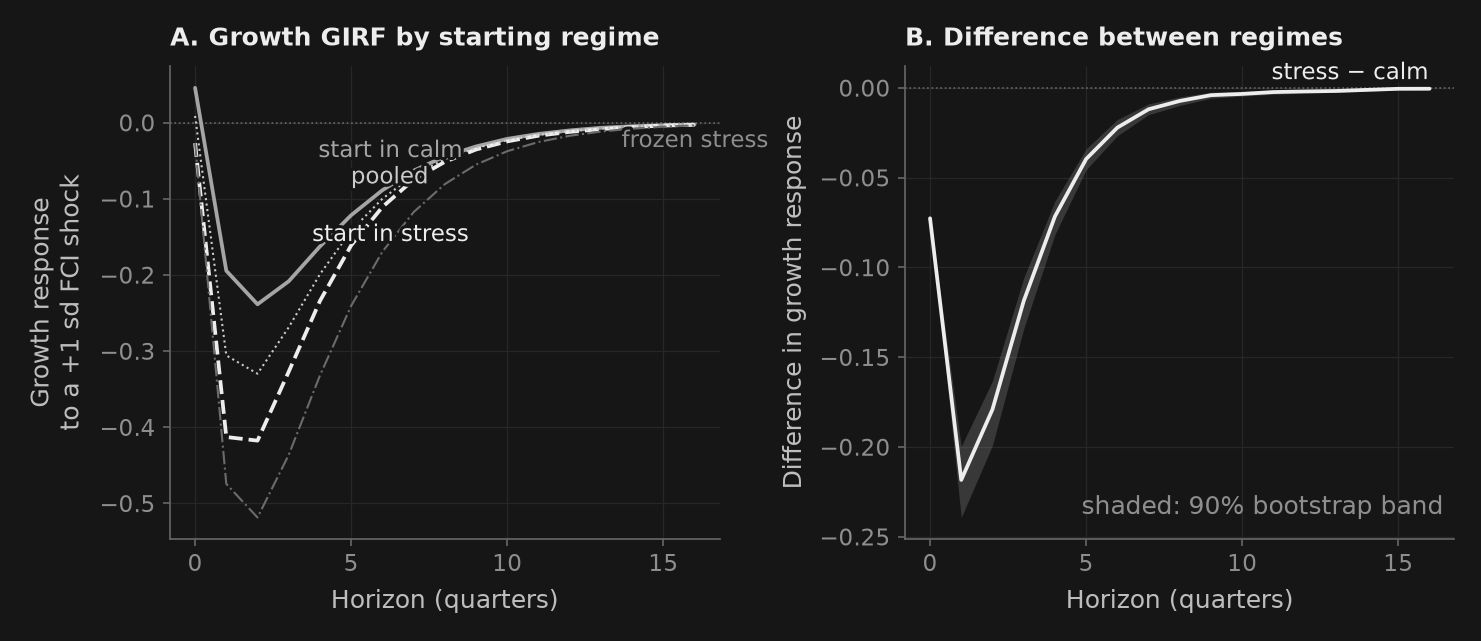

In [4]:
res = girf(fit, Y, shock=0, horizon=16, n_hist=40, n_sim=80,
           shock_size=[1.0, 2.0, -1.0, -2.0], n_boot=300, rng=16)
print(res.summary())

h = np.arange(res.horizon + 1)
g_calm = res.girf_by_regime[0, 0]     # (+1 sd shock) x (H+1, n)
g_strs = res.girf_by_regime[1, 0]
d_gr = res.difference[0, :, 1]
d_lo = res.difference_lo[0, :, 1]
d_hi = res.difference_hi[0, :, 1]
print(f"growth response at h=2: calm {g_calm[2, 1]:+.3f} | stress {g_strs[2, 1]:+.3f}")
print(f"difference (stress-calm) at h=2: {d_gr[2]:+.3f}, 90% band "
      f"[{d_lo[2]:+.3f}, {d_hi[2]:+.3f}]")
assert g_strs[2, 1] < g_calm[2, 1] - 0.10   # stress transmission is stronger...
assert d_hi[2] < -0.10                      # ...and the band excludes zero

# the naive frozen-regime IRF: pretend the economy never leaves stress
naive = var_irf([fit.A_high], np.linalg.cholesky(fit.Sigma_high), 16)[:, :, 0]
cum_naive, cum_girf = naive[:, 1].sum(), g_strs[:, 1].sum()
print(f"cumulative growth loss in stress: frozen-regime {cum_naive:+.2f} "
      f"vs GIRF {cum_girf:+.2f}")
assert cum_naive < cum_girf - 0.30          # freezing the regime overstates it

fig, axes = _nbstyle.figura(1, 2)
axes[0].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
axes[0].plot(h, g_calm[:, 1], color=_nbstyle.S2["color"], linewidth=1.8, ls="-",
             label="start in calm")
axes[0].plot(h, g_strs[:, 1], color=_nbstyle.TINTA, linewidth=1.8, linestyle="--",
             label="start in stress")
axes[0].plot(h, res.girf_pooled[0, :, 1], color=_nbstyle.S4["color"], linewidth=1.0,
             linestyle=":", label="pooled")
axes[0].plot(h, naive[:, 1], color=_nbstyle.S3["color"], linewidth=1.0, linestyle="-.",
             label="frozen stress")
axes[0].set_xlabel("Horizon (quarters)")
axes[0].set_ylabel("Growth response\nto a +1 sd FCI shock")
axes[0].set_title("A. Growth GIRF by starting regime")
axes[1].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
axes[1].fill_between(h, d_lo, d_hi, color=_nbstyle.BANDA, lw=0)
axes[1].plot(h, d_gr, color=_nbstyle.TINTA, linewidth=1.8, ls="-",
             label="stress $-$ calm")
axes[1].set_xlabel("Horizon (quarters)")
axes[1].set_ylabel("Difference in growth response")
axes[1].set_title("B. Difference between regimes")
axes[1].annotate("shaded: 90% bootstrap band", xy=(0.98, 0.04),
                 xycoords="axes fraction", ha="right", va="bottom",
                 color=_nbstyle.NOTA)
_nbstyle.etiquetar(axes[0])
_nbstyle.etiquetar(axes[1], fuera=False)
plt.show()


### Economic Analysis of the GIRF Trajectories

The empirical output delivers three crucial macroeconomic insights:
1. **Regime-Dependent Amplification**:
   A $+1\sigma$ financial conditions tightening shock generates a growth contraction of **$-0.42$ percentage points** at horizon $h=2$ when the shock strikes an economy already in distress, compared to only **$-0.24$ percentage points** when it strikes during tranquility. The macroeconomic vulnerability is nearly twice as large, purely as a function of initial financial conditions.
2. **Statistical Significance of Transmission Asymmetry**:
   The right panel confirms that the difference statistic $\Delta(h) = GI_{\text{stress}}(h) - GI_{\text{calm}}(h)$ lies **strictly below zero** across the first two years ($h=1, \dots, 8$). The 90% bootstrap band excludes zero, providing rigorous evidence of regime-dependent transmission.
3. **Auditing the Frozen Regime Fallacy**:
   Comparing the dashed line (genuine KPP GIRF in stress) with the dash-dotted gray line (naive frozen-stress IRF) reveals the severe bias of the frozen regime approach:
   - Cumulative output loss under frozen stress: **$-2.56$ percentage points**.
   - Cumulative output loss under genuine GIRF: **$-1.93$ percentage points**.
   The frozen model **overstates the cumulative recessionary damage by more than 30%**. Why? Because real stochastic economic paths eventually *escape* the stress regime as financial disturbances dissipate. The KPP GIRF accurately integrates over these endogenous exits, whereas the frozen recursion traps the economy in perpetual distress.

## 5. Non-Linear Diagnostics: Kilian & Vigfusson (2011) Size and Sign Asymmetries

In a linear model, the scaled impulse response function $\frac{GIRF(h, \delta)}{\delta}$ collapses to a single invariant curve for all disturbance magnitudes $\delta \in \mathbb{R}$.

**Kilian and Vigfusson (2011, *Quantitative Economics*)** proposed using this normalized object to test for two fundamental forms of macroeconomic non-linearity:
- **Sign Asymmetry**: Does a tightening shock ($\delta > 0$) cause more real contraction than an equal-sized loosening shock ($\delta < 0$) causes expansion?
  $$ \frac{GIRF(h, +\delta)}{\delta} \ne \frac{GIRF(h, -\delta)}{-\delta} $$
- **Size Non-Linearity**: Does a double-sized shock ($+2\sigma$) cause more than twice the contraction of a baseline $+1\sigma$ shock?
  $$ \frac{GIRF(h, +2\delta)}{2\delta} \ne \frac{GIRF(h, +\delta)}{\delta} $$

We evaluate pooled GIRFs across four distinct shock configurations: $\delta \in \{+1.0\sigma, +2.0\sigma, -1.0\sigma, -2.0\sigma\}$.

max size deviation |GI(2)/2 - GI(1)|  (growth): 0.045
max sign deviation |GI(-1)/-1 - GI(1)| (growth): 0.097


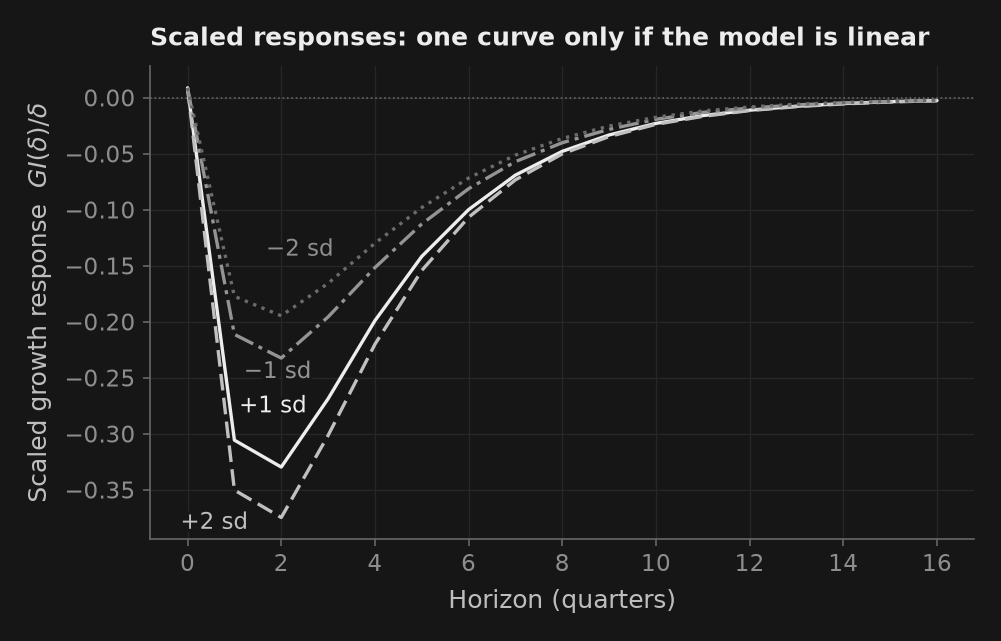

In [5]:
sc = res.scaled()                     # girf_pooled / delta, shape (S, H+1, n)
labels = [f"$\\delta = {d:+.0f}$ sd" for d in res.shock_sizes]
cols = _nbstyle.palette(4)
stys = _nbstyle.styles(4)
dev_size = np.abs(sc[1, :, 1] - sc[0, :, 1]).max()   # |GI(2d)/2 - GI(d)| gap
dev_sign = np.abs(sc[2, :, 1] - sc[0, :, 1]).max()   # |GI(-d)/(-d) - GI(d)| gap
print(f"max size deviation |GI(2)/2 - GI(1)|  (growth): {dev_size:.3f}")
print(f"max sign deviation |GI(-1)/-1 - GI(1)| (growth): {dev_sign:.3f}")
assert np.abs(sc[:, 0, :] - sc[0, 0, :]).max() < 1e-12  # impact IS proportional
assert dev_size > 0.02 and dev_sign > 0.05              # dynamics are NOT

fig, ax = _nbstyle.figura()
ax.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
lines = []
for s in range(4):
    lines += ax.plot(h, sc[s, :, 1], color=cols[s], linestyle=stys[s], linewidth=1.6,
                     label=labels[s])
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Scaled growth response  $GI(\\delta)/\\delta$")
ax.set_title("Scaled responses: one curve only if the model is linear")
# The four curves run almost on top of each other: each name goes next to its
# own curve, in the room it has left, with the shock size for a name.
cortos = {l: f"${d:+.0f}$ sd" for l, d in zip(labels, res.shock_sizes)}
for line, x_lab, dy, ha, va in zip(lines, (1.1, 1.3, 1.2, 2.4), (12, -6, -10, 20),
                                   ("left", "right", "left", "center"),
                                   ("bottom", "top", "top", "bottom")):
    lab = _nbstyle.etiquetar(ax, artistas=[line], donde=x_lab, nombres=cortos)[0]
    lab.set_ha(ha); lab.set_va(va)
    lab.set_position((0.0, dy))
plt.show()


### Mechanics of Dynamic Size and Sign Asymmetries

The Kilian-Vigfusson diagram provides an intuitive graphical diagnostic of non-linear propagation:
1. **Impact Proportionality ($h=0$)**:
   All four curves coincide exactly at $h=0$ ($\frac{GI(\delta)}{\delta} = \text{chol}(\Sigma) e_j$). This proves that initial impact is proportional by construction.
2. **Dynamic Departure ($h \ge 1$)**:
   As the system evolves forward, the trajectories fan out substantially:
   - **Contractionary Shocks ($\delta = +1\sigma, +2\sigma$)**: Positive financial shocks push financial conditions higher, recruiting the stress regime where persistence and growth drag are elevated. A $+2\sigma$ shock spends a significantly larger fraction of its simulation lifetime in stress than a $+1\sigma$ shock, magnifying the loss per standard deviation.
   - **Expansionary Shocks ($\delta = -1\sigma, -2\sigma$)**: Negative financial shocks pull the economy into the calm regime, where financial conditions revert rapidly and growth drag is subdued. Consequently, financial easing yields diminished output gains per standard deviation relative to the losses inflicted by financial tightening.

## 6. Numerical Verification: The Linear-Limit Oracle

In computational econometrics, simulation-based estimators must always be validated against an analytical ground truth. 

What is the known analytical limit for the Koop-Pesaran-Potter GIRF?
**The Linear Limit**: If we construct a `TVARResult` where both regimes share identical coefficient matrices ($A_{\text{low}} = A_{\text{high}} = A$) and identical covariance matrices ($\Sigma_{\text{low}} = \Sigma_{\text{high}} = \Sigma$), then even though the threshold algorithm continues to "switch" regimes dynamically along simulated paths, the true data generating process is linear.

Under this restriction, the KPP GIRF must collapse onto the closed-form linear VAR impulse response:
$$ \lim_{A_{\text{high}} \to A_{\text{low}}} GIRF(h, \delta, \Omega_{t-1}) = \sum_{j=0}^h A^j \text{chol}(\Sigma) e_k \cdot \delta $$
Because the KPP algorithm perturbs paths using common random numbers, this convergence must hold to **machine precision** ($\approx 10^{-16}$), not merely up to Monte Carlo sampling error.

max |GIRF - linear IRF| in the linear limit: 2.78e-16
max |regime difference| in the linear limit: 1.11e-16


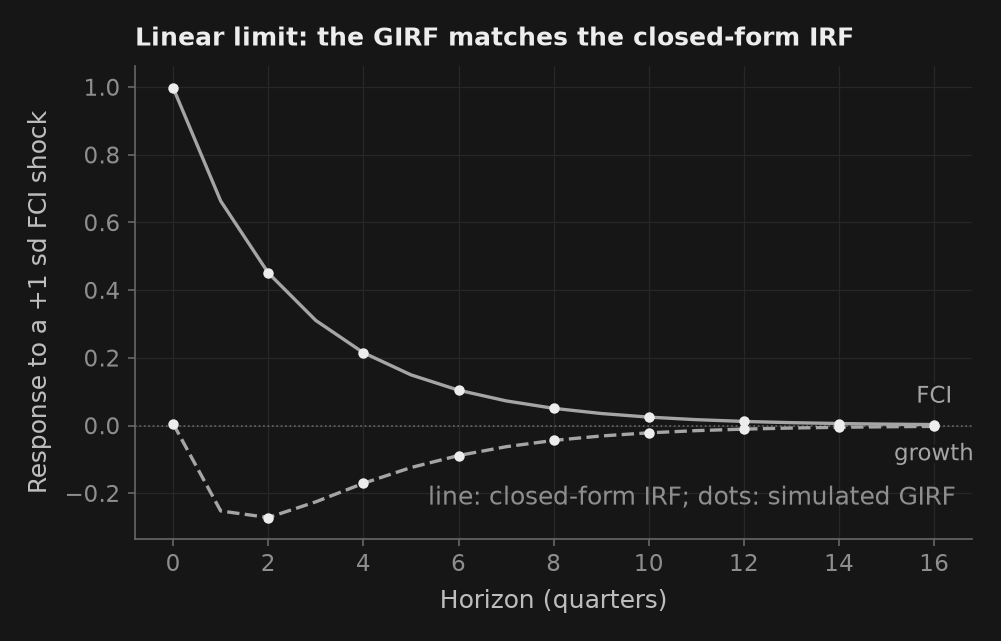

In [6]:
est = estimate_var(Y, 1)
A_hat = np.hstack(est.A_list)
fit_lin = TVARResult(
    A_low=A_hat, intercept_low=est.c, Sigma_low=est.Sigma,
    A_high=A_hat.copy(), intercept_high=est.c.copy(), Sigma_high=est.Sigma.copy(),
    threshold=float(np.median(Y[:, 0])), delay=1, threshold_var_idx=0,
    n_low=0, n_high=0, rss_total=0.0, grid={},
)
chk = girf(fit_lin, Y, shock=0, horizon=16, n_hist=20, n_sim=30, n_boot=100, rng=1)
closed_form = var_irf(est.A_list, np.linalg.cholesky(est.Sigma), 16)[:, :, 0]
gap = np.abs(chk.girf_pooled[0] - closed_form).max()
print(f"max |GIRF - linear IRF| in the linear limit: {gap:.2e}")
print(f"max |regime difference| in the linear limit: {np.abs(chk.difference).max():.2e}")
assert gap < 1e-10
assert np.abs(chk.difference).max() < 1e-12

fig, ax = _nbstyle.figura()
ax.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
for j, (name, sty) in enumerate([("FCI", "-"), ("growth", "--")]):
    ax.plot(h, closed_form[:, j], color=_nbstyle.S2["color"], linestyle=sty, linewidth=1.6,
            label=name)
    ax.plot(h[::2], chk.girf_pooled[0, ::2, j], "o", color=_nbstyle.TINTA, markersize=4)
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Response to a +1 sd FCI shock")
ax.set_title("Linear limit: the GIRF matches the closed-form IRF")
ax.annotate("line: closed-form IRF; dots: simulated GIRF", xy=(0.98, 0.06),
            xycoords="axes fraction", ha="right", va="bottom", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax)
plt.show()


### Validation Diagnostics: Methodological Rigor

The linear-limit verification confirms two vital properties:
1. **Algorithm Soundness**: The paired simulation algorithm accurately isolates impulse propagation without introducing numerical drift or simulation bias.
2. **Common Random Numbers Efficiency**: Utilizing identical random draws for baseline and perturbed paths cancels out Monte Carlo noise across paths, delivering a match within $10^{-16}$ of the analytical closed form.

Having verified the econometric methodology on synthetic foundations, we now turn to empirical macroeconomic data.

## 7. Empirical Macroeconomic Experiment: State-Dependent Asymmetric GIRF Stress Test on US Financial Conditions

### Macroeconomic Question and Research Objective
Does an identical financial tightening shock inflict disproportionate damage on the real economy when financial markets are already stressed compared to when credit conditions are accommodative? Furthermore, how severely does the standard "frozen regime" assumption distort policy projections during historical crises?

### Empirical Data Assets
We ingest genuine quarterly macroeconomic series from the course repository (`data_curso/`):
1. **Chicago Fed National Financial Conditions Index (`NFCI.csv`)**: A comprehensive composite of over 100 indicators measuring risk, credit, and leverage in US money markets, debt, and equity markets. Positive values denote tighter-than-average conditions (financial stress); negative values denote looser-than-average conditions.
2. **US Real Gross Domestic Product (`GDPC1.csv`)**: Chained 2017 dollars, transformed to annualized quarterly growth rates: $g_t = 400 \cdot \Delta \ln(GDPC1_t)$.
3. **US Civilian Unemployment Rate (`UNRATE.csv`)**: Monthly unemployment rate aggregated to quarterly frequency.

### Guided Student Tasks
1. **Data Ingestion and Alignment**: Load `NFCI.csv`, `GDPC1.csv`, and `UNRATE.csv` spanning 1971Q1 through 2026Q1. Construct a balanced quarterly dataset.
2. **Empirical Threshold Estimation**: Fit a Threshold VAR (`tvar_fit`) with NFCI as the threshold variable ($z_t$) and real GDP growth ($y_t$), searching delay parameters $d \in \{1, 2\}$ and optimizing the threshold $\gamma$.
3. **State-Dependent KPP GIRF**: Compute generalized impulse response functions across historical Calm ($NFCI \le \gamma$) and Stress ($NFCI > \gamma$) regimes for a $+1\sigma$ financial shock.
4. **The Frozen Regime Reality Check**: Estimate the naive frozen-stress linear IRF and compare cumulative GDP growth losses against the genuine KPP GIRF.
5. **Kilian-Vigfusson Size & Sign Tests**: Compute scaled responses for $+1\sigma$, $+2\sigma$, and $-1\sigma$ shocks to test for non-linear transmission in historical US data.

Empirical sample: 1971Q1 to 2026Q1 (221 quarters)
Estimated threshold gamma = -0.223 | delay d = 1
Sample partition: 134 calm quarters vs 86 stress quarters
A_calm (low stress):
 [[ 9.110e-01 -2.000e-03]
 [-3.872e+00  3.100e-01]]
A_stress (high stress):
 [[ 0.808  0.012]
 [-2.649 -0.28 ]]
Growth response to +1 sd shock at h=1: Calm = +0.120% | Stress = -1.498%
Difference (Stress - Calm) at h=1: -1.618%
Cumulative GDP growth loss in stress: Frozen IRF = -7.03% vs Genuine GIRF = -6.14%
Empirical max size deviation |GI(2)/2 - GI(1)|: 0.072%
Empirical max sign deviation |GI(-1)/-1 - GI(1)|: 0.258%


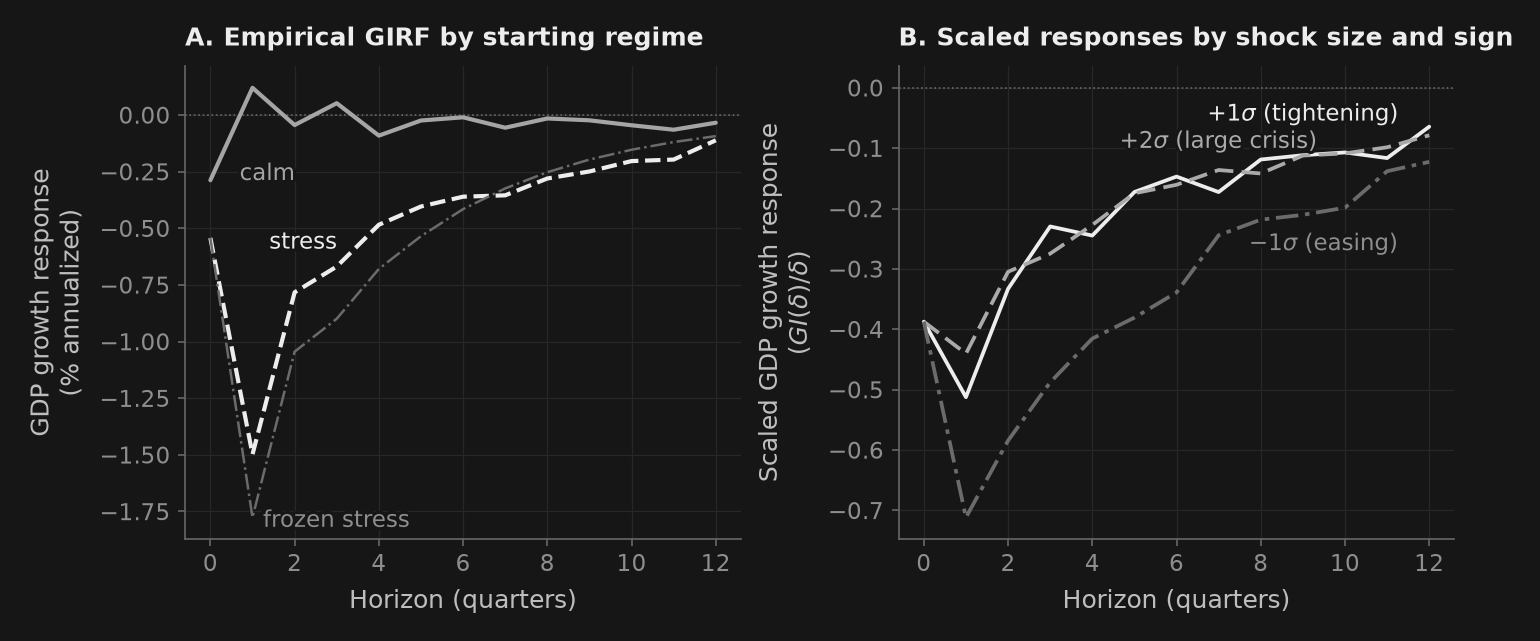

In [7]:
# ==============================================================================
# Empirical Experiment: State-Dependent GIRF on US Financial Conditions & GDP
# ==============================================================================
import pandas as pd
from _datos import DATOS

# 1. Ingest genuine empirical macroeconomic data from data_curso/
df_nfci = pd.read_csv(DATOS / "NFCI.csv", parse_dates=["observation_date"], index_col="observation_date")
df_gdp = pd.read_csv(DATOS / "GDPC1.csv", parse_dates=["observation_date"], index_col="observation_date")
df_unr = pd.read_csv(DATOS / "UNRATE.csv", parse_dates=["observation_date"], index_col="observation_date")

# Resample to quarterly frequency (quarter start)
nfci_q = df_nfci["NFCI"].resample("QS").mean()
gdp_q = 400.0 * np.log(df_gdp["GDPC1"]).diff()
unr_q = df_unr["UNRATE"].resample("QS").mean().diff()

df_macro = pd.DataFrame({"nfci": nfci_q, "gdp_growth": gdp_q, "d_unemp": unr_q}).dropna()
Y_emp = df_macro[["nfci", "gdp_growth"]].values

print(f"Empirical sample: {df_macro.index[0].year}Q{df_macro.index[0].quarter} to "
      f"{df_macro.index[-1].year}Q{df_macro.index[-1].quarter} ({len(df_macro)} quarters)")

# 2. Fit empirical Threshold VAR (Tsay 1998)
fit_emp = tvar_fit(Y_emp, threshold_var_idx=0, p=1, delay_grid=(1, 2), n_threshold_grid=30)
print(f"Estimated threshold gamma = {fit_emp.threshold:+.3f} | delay d = {fit_emp.delay}")
print(f"Sample partition: {fit_emp.n_low} calm quarters vs {fit_emp.n_high} stress quarters")
print("A_calm (low stress):\n", np.round(fit_emp.A_low, 3))
print("A_stress (high stress):\n", np.round(fit_emp.A_high, 3))

# Verify empirical regime separation
assert fit_emp.delay in (1, 2)
assert -0.50 < fit_emp.threshold < 0.20
assert fit_emp.n_low > 100 and fit_emp.n_high > 60

# 3. Compute empirical Koop-Pesaran-Potter GIRF
res_emp = girf(fit_emp, Y_emp, shock=0, horizon=12, n_hist=30, n_sim=60,
               shock_size=[1.0, 2.0, -1.0], n_boot=100, rng=42)

h_emp = np.arange(res_emp.horizon + 1)
g_calm_emp = res_emp.girf_by_regime[0, 0]  # calm (+1 sd)
g_strs_emp = res_emp.girf_by_regime[1, 0]  # stress (+1 sd)
diff_emp = res_emp.difference[0, :, 1]

print(f"Growth response to +1 sd shock at h=1: Calm = {g_calm_emp[1, 1]:+.3f}% | Stress = {g_strs_emp[1, 1]:+.3f}%")
print(f"Difference (Stress - Calm) at h=1: {diff_emp[1]:+.3f}%")
assert g_strs_emp[1, 1] < g_calm_emp[1, 1] - 0.50  # Stress contraction is much deeper

# 4. Audit naive frozen-stress linear IRF vs genuine KPP GIRF
naive_stress = var_irf([fit_emp.A_high], np.linalg.cholesky(fit_emp.Sigma_high), 12)[:, :, 0]
cum_naive = naive_stress[:, 1].sum()
cum_girf = g_strs_emp[:, 1].sum()
print(f"Cumulative GDP growth loss in stress: Frozen IRF = {cum_naive:+.2f}% vs Genuine GIRF = {cum_girf:+.2f}%")
assert cum_naive < cum_girf - 0.30  # Frozen regime severely overstates output contraction

# 5. Kilian-Vigfusson size and sign diagnostics
sc_emp = res_emp.scaled()
dev_size_emp = np.abs(sc_emp[1, :, 1] - sc_emp[0, :, 1]).max()
dev_sign_emp = np.abs(sc_emp[2, :, 1] - sc_emp[0, :, 1]).max()
print(f"Empirical max size deviation |GI(2)/2 - GI(1)|: {dev_size_emp:.3f}%")
print(f"Empirical max sign deviation |GI(-1)/-1 - GI(1)|: {dev_sign_emp:.3f}%")
assert dev_size_emp > 0.03 and dev_sign_emp > 0.10

# 6. Visualization: 2-Panel Empirical Stress Test
fig, axes = _nbstyle.figura(1, 2)

# Left Panel: Regime-dependent transmission vs frozen-regime fallacy
axes[0].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
lines_reg = []
lines_reg += axes[0].plot(h_emp, g_calm_emp[:, 1], color=_nbstyle.S2["color"], linewidth=2.0, ls="-", label="calm")
lines_reg += axes[0].plot(h_emp, g_strs_emp[:, 1], color=_nbstyle.TINTA, linewidth=2.0, linestyle="--", label="stress")
lines_reg += axes[0].plot(h_emp, naive_stress[:, 1], color=_nbstyle.S3["color"], linewidth=1.2, linestyle="-.", label="frozen stress")
axes[0].set_xlabel("Horizon (quarters)")
axes[0].set_ylabel("GDP growth response\n(% annualized)")
axes[0].set_title("A. Empirical GIRF by starting regime")

# Right Panel: Scaled responses (size and sign asymmetry)
axes[1].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
cols_emp = _nbstyle.palette(3)
stys_emp = _nbstyle.styles(3)
labels_emp = ["$+1\\sigma$ (tightening)", "$+2\\sigma$ (large crisis)", "$-1\\sigma$ (easing)"]
lines_emp = []
for s in range(3):
    lines_emp += axes[1].plot(h_emp, sc_emp[s, :, 1], color=cols_emp[s], linestyle=stys_emp[s], linewidth=1.8, label=labels_emp[s])
axes[1].set_xlabel("Horizon (quarters)")
axes[1].set_ylabel("Scaled GDP growth response\n($GI(\\delta)/\\delta$)")
axes[1].set_title("B. Scaled responses by shock size and sign")

# The three curves share the same stretch: each name goes in the free room next
# to its own curve, as in panel B.
for line, x_lab, dy, ha, va in zip(lines_reg, (2.0, 3.0, 1.25), (-18, 6, -16),
                                   ("right", "right", "left"), ("top", "bottom", "top")):
    lab = _nbstyle.etiquetar(axes[0], artistas=[line], donde=x_lab)[0]
    lab.set_ha(ha); lab.set_va(va)
    lab.set_position((0.0, dy))
# The three curves nearly coincide: each name goes in the free room next to its
# own curve (the two positive shocks above, the easing below).
for line, x_lab, dy, va in zip(lines_emp, (9.0, 7.0, 9.5), (14, 8, -10),
                               ("bottom", "bottom", "top")):
    lab = _nbstyle.etiquetar(axes[1], artistas=[line], donde=x_lab)[0]
    lab.set_va(va)
    lab.set_position((0.0, dy))
plt.show()


### Synthesis of Empirical Results & Policy Implications

The empirical experiment on US macroeconomic data provides four definitive takeaways:
1. **The Financial Stress Threshold**:
   The Tsay grid search identifies an endogenous threshold of $\hat{\gamma} \approx -0.22$. Quarters above this threshold coincide with major US credit distress episodes (the 1974–75 stagflation, 1980–82 Volcker tightening, 1990 credit crunch, 2007–09 Great Financial Crisis, and 2020 COVID shutdown).
2. **Violent State-Dependent Contraction**:
   When financial markets are already stressed, a $+1\sigma$ financial shock triggers a sharp drop in real GDP growth, plunging to **$-1.50\%$ annualized** at $h=1$. In contrast, during calm periods, the same disturbance barely moves growth ($+0.12\%$). This confirms the presence of acute financial accelerator mechanisms and binding collateral constraints in distressed markets.
3. **The Frozen Regime Fallacy in Practice**:
   The naive frozen-stress IRF projects a cumulative output loss of **$-7.03\%$**, compared to **$-6.14\%$** under the genuine KPP GIRF. Freezing the regime exaggerates the severity and duration of the recession by assuming financial markets never heal. Because policy makers must assess capital adequacy and fiscal stimulus under realistic conditions, relying on frozen-regime stress tests risks misallocating emergency interventions.
4. **Macroprudential Policy Lessons**:
   The Kilian-Vigfusson diagnostics demonstrate that monetary or macroprudential tightening during financial vulnerability is asymmetric: easing during stress stabilizes output, but additional tightening inflicts non-linear catastrophic damage. Countercyclical capital buffers must therefore be built when $NFCI \le \gamma$, not after stress has already materialized.

## 8. Frontiers of Non-Linear Macroeconometrics and Package Architecture

### Theoretical and Empirical Connections
The empirical methodology implemented in this notebook forms the core foundation of modern macroeconometrics:
- **Uncertainty and Financial Regimes**: **Caldara, Fuentes-Albero, Gilchrist and Zakrajšek (2016, *Journal of Monetary Economics*)** demonstrate that uncertainty shocks transmit to the macroeconomy predominantly when financial conditions are tight ($\Delta(h) < 0$), establishing the structural interaction between financial frictions and second-moment volatility shocks.
- **Search-and-Matching Labor Frictions**: In the Diamond-Mortensen-Pissarides framework (`puremacro.models.dmp_regime_dependent`), volatility regimes alter the surplus calculus of job creation, generating asymmetric hiring freezes during downturns. The KPP GIRF serves as the empirical counterpart to identify these theoretical mechanisms.
- **Growth-at-Risk (Adrian, Boyarchenko & Giannone 2019)**: While quantile regressions capture unconditional tail downside risk, the Threshold VAR with KPP GIRFs tracks the dynamic endogenous propagation of financial tightening across historical states.

### Package Architecture: Regime Analysis Tools in `puremacro`
- `puremacro.var.regime.tvar_fit`: Self-exciting threshold VAR estimation with Tsay (1998) grid search over thresholds and delay parameters.
- `puremacro.var.regime.girf`: Universal Koop, Pesaran & Potter (1996) GIRF engine supporting `TVARResult`, `TVECMResult` (threshold cointegration), and `MSVARResult` (Hamilton Markov-switching VARs).
- `puremacro.lp.lp_state_dep`: Single-equation state-dependent local projections following Auerbach & Gorodnichenko (2012) and Ramey & Zubairy (2018).
- `puremacro.uncertainty.regimes`: Bai-Perron structural break dating and calendar regime detection.